
# <span style="color:rgb(213,80,0)">ECM Fitting for lithium\-ion batteries</span>

## Impedance computation

We setup a P2D model and compute the impedance response


In [1]:
jsonstruct_material = parseBattmoJson(fullfile('ParameterData','ParameterSets','Chen2020','chen2020_lithium_ion_battery.json'));
jsonstruct_geometry = parseBattmoJson(fullfile('Examples', 'JsonDataFiles', 'geometryChen.json'));
jsonstruct_base     = mergeJsonStructs({jsonstruct_material, jsonstruct_geometry});

jsonstruct_base.NegativeElectrode.Coating.ActiveMaterial.Interface.useDoubleLayerCapacity = true;

c_ne = 29.866*mol/litre;
c_pe = 17.038*mol/litre;

p_diffusion              = 0;
p_reactionRate           = 0;
p_doubleLayerCapacitance = 0;
base_diff_anode          = 1.3135e-15;
base_rate_anode          = 5.031e-11;
base_cdl                 = 0.2;

val_diff_anode = base_diff_anode * (10^p_diffusion);
val_rate_anode = base_rate_anode * (10^p_reactionRate);
val_cdl = base_cdl * (10^p_doubleLayerCapacitance);

jsonstruct = jsonstruct_base;

jsonstruct.NegativeElectrode.Coating.ActiveMaterial.SolidDiffusion.referenceDiffusionCoefficient = val_diff_anode;
jsonstruct.NegativeElectrode.Coating.ActiveMaterial.Interface.reactionRateConstant               = val_rate_anode;
jsonstruct.NegativeElectrode.Coating.ActiveMaterial.Interface.doubleLayerCapacitance             = val_cdl;


Setup P2D model from the parameter set <samp>jsonstruct</samp>


In [2]:
[model, inputparams, ~] = setupModelFromJson(jsonstruct);


We use a dedicated function to compute the initial state for the given electrode concentrations.


In [3]:
initstate = initStateChen2020(model, c_ne, c_pe);
options = [];
options.stateInitialization.initializationSetup = 'given state';
options.stateInitialization.computeSteadyState = false;


setup input for <samp>ImpedanceSolver</samp>


In [4]:
extrastructs = [];
extrastructs.initstate = initstate;


setup impedance solver and compute the Impedance for a given set of frequencies



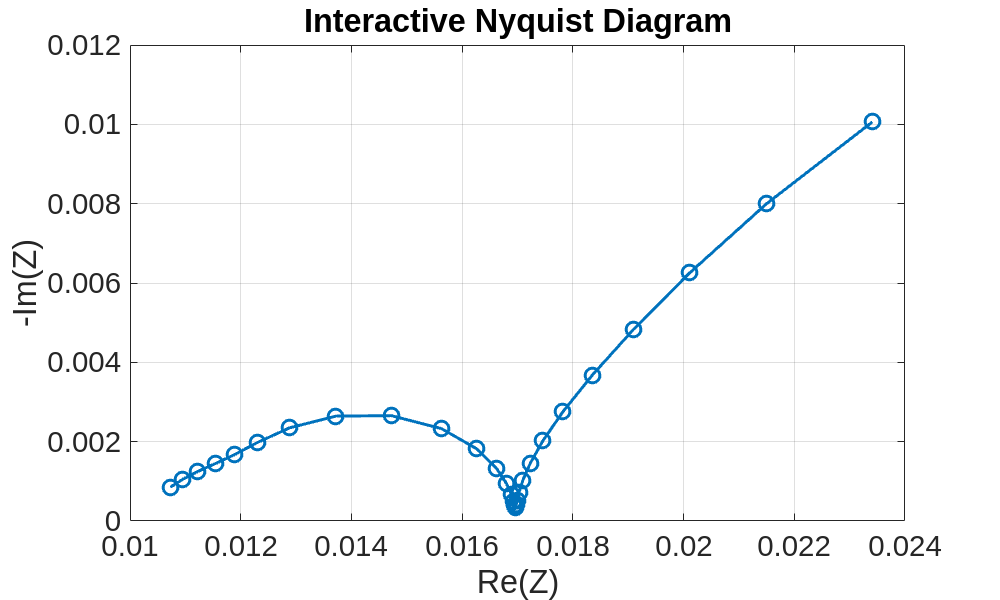

In [5]:
impsolv = ImpedanceSolver(inputparams, options, extrastructs);
frequencies = logspace(-2, 3, 30);

Z = impsolv.computeImpedance(frequencies);

figure('Name', 'Nyquist Diagram');
plot(real(Z), -imag(Z), '-o', 'LineWidth', 2, 'Color', '#0072BD');
grid on;
xlabel('Re(Z)');
ylabel('-Im(Z)');
title('Interactive Nyquist Diagram');


The impact of diffusion is mainly seen on the tail at low frequencies. While a larger coefficient does not have much of an impact, using a very small one shows how strongly the diffusion phenomenon is linked to this tail.


The double\-layer capacitance affects the first semicircle, as the frequency at its peak is governed by the relation $f_{\max } =\frac{1\;}{2\pi R_{\textrm{CT}} C_{\textrm{DL}} }$ . A large capacitance will result in a lower $f_{\max }$ (a shift to the left, as frequencies are plotted inversely), while a small one will shift the center of the first semicircle to the right.


Finally, the influence of the reaction rate on the Nyquist diagram is clearly evident. A more facile reaction (i.e., a higher reaction rate) leads to a lower charge\-transfer resistance. As this parameter dictates the width of the first semicircle, it virtually vanishes at high reaction rates and broadens considerably at lower ones.

## Calibration of ECM parameters

Impedance is the opposition to alternating current presented by the combined effect of resistance and reactance in a circuit. It is obtained with the ratio of complex voltage and complex current : $Z=U/I$ . It extends the concept of resistance to alternating current (AC) circuits.


We tried through our optimization algorithm to fit different battery models to ECM through five parameters, $R_0$ , $R_1$ , $C_1$ , $R_2$ and $C_2$ . The aim of the study is to obtain the set of parameters as close as possible to the real impedance curve with the 2\-RC Impedance function $Z=R_0 +\frac{R_1 }{1+jR_1 C_1 \omega }+\frac{R_2 }{1+jR_2 C_2 \omega }$ .

## Calibration using pertubed initial data

We compute the impedance response of the ECM model for a given set of parameters and use it as an input in our calibration algorithm. We choose a initial guess for the parameters that is perturbed from the true values. The optimization algorithm should be able to recover the true parameters.


It:  0 | val: 1.373e-31 | ls-its: NaN | pgrad: 1.164e-12
It:  1 | val: 1.373e-31 | ls-its:   0 | pgrad: 1.152e-12
Stopped because reached gradTol = 1.000000e-05.


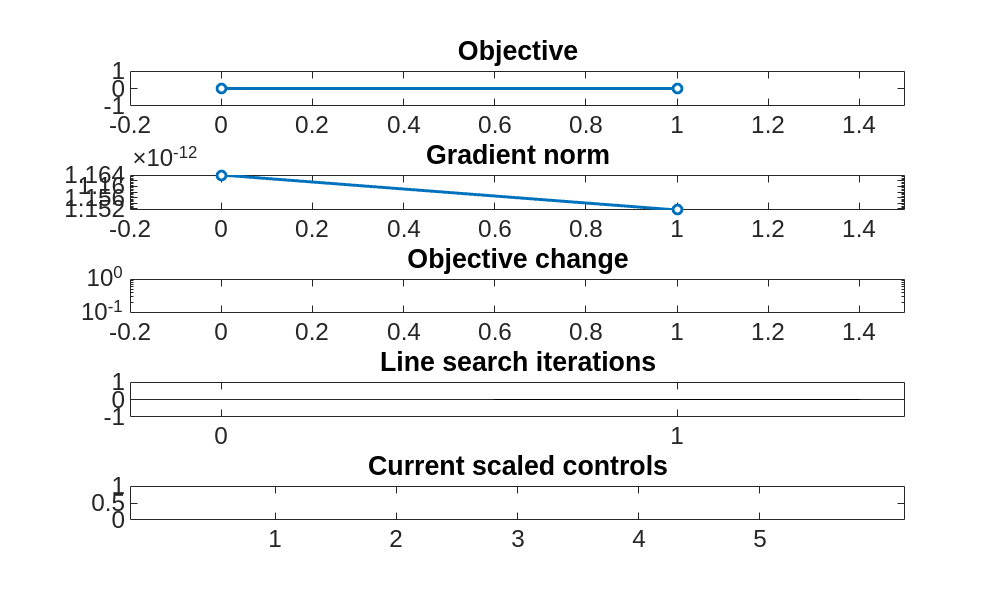

In [6]:
omega = logspace(-4, 2, 50);
params = [0.05052, 1.12673, 59119.9, 0.03155, 11054.0];
[Z_re_exp, Z_im_exp] = load_nyquist(params, omega);

params0 = [0.05052, 1.12673, 59119.9, 0.03155, 11054.0];  % initial condition: C1>2*C2

a = 1000;

pmin = params0 / a;
pmax = params0 * a;
scales = [pmin, pmax];

feis = FittingEIS(params0, scales, Z_re_exp, Z_im_exp, omega);

[~, ~, best_params, fitting_error] = feis.optimizationBFGS();


plot the results



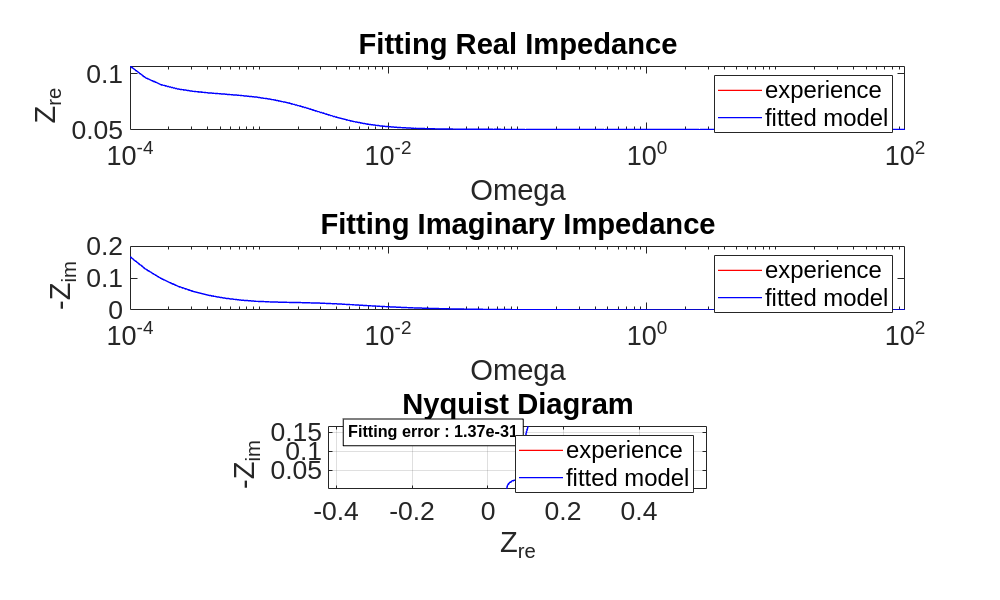

In [7]:
feis.plotresults_thevenin(best_params, fitting_error);

## Calibration from experimental data

We use data from the Ank's paper ([http://dx.doi.org/10.1149/1945\-7111/ad14d0](http://dx.doi.org/10.1149/1945-7111/ad14d0)) to calibrate the ECM parameters.


In [8]:
filename = fullfile(battmoDir(), 'Battery', 'EquivalentCircuitModel', 'calibration', 'utils', 'ank_data.csv');
data = readmatrix(filename);

omega    = data(:, 1);
Z_re_exp = data(:, 2);
Z_im_exp = data(:, 3);


We choose the following Initial guess


It:  0 | val: 3.717e-01 | ls-its: NaN | pgrad: 1.563e+02
It:  1 | val: 3.716e-01 | ls-its:   3 | pgrad: 1.561e+02
It:  2 | val: 1.870e-01 | ls-its:   8 | pgrad: 1.549e+02
It:  3 | val: 1.827e-01 | ls-its:   3 | pgrad: 1.616e+03
It:  4 | val: 1.596e-01 | ls-its:   2 | pgrad: 1.673e+03
It:  5 | val: 1.419e-01 | ls-its:   2 | pgrad: 4.695e+02
It:  6 | val: 8.869e-02 | ls-its:   1 | pgrad: 1.096e+03
It:  7 | val: 6.885e-02 | ls-its:   1 | pgrad: 2.369e+02
It:  8 | val: 6.869e-02 | ls-its:   1 | pgrad: 1.020e+02
It:  9 | val: 6.869e-02 | ls-its:   1 | pgrad: 1.253e+01
It: 10 | val: 6.866e-02 | ls-its:   2 | pgrad: 6.159e+00
It: 11 | val: 6.864e-02 | ls-its:   1 | pgrad: 3.511e+01
It: 12 | val: 6.862e-02 | ls-its:   1 | pgrad: 2.040e+01
It: 13 | val: 6.862e-02 | ls-its:   2 | pgrad: 1.882e+01
It: 14 | val: 6.862e-02 | ls-its:   1 | pgrad: 3.677e+00
It: 15 | val: 6.861e-02 | ls-its:   2 | pgrad: 2.463e+00
It: 16 | val: 6.860e-02 | ls-its:   1 | pgrad: 1.650e+01
It: 17 | val: 6.860e-02 | ls-it


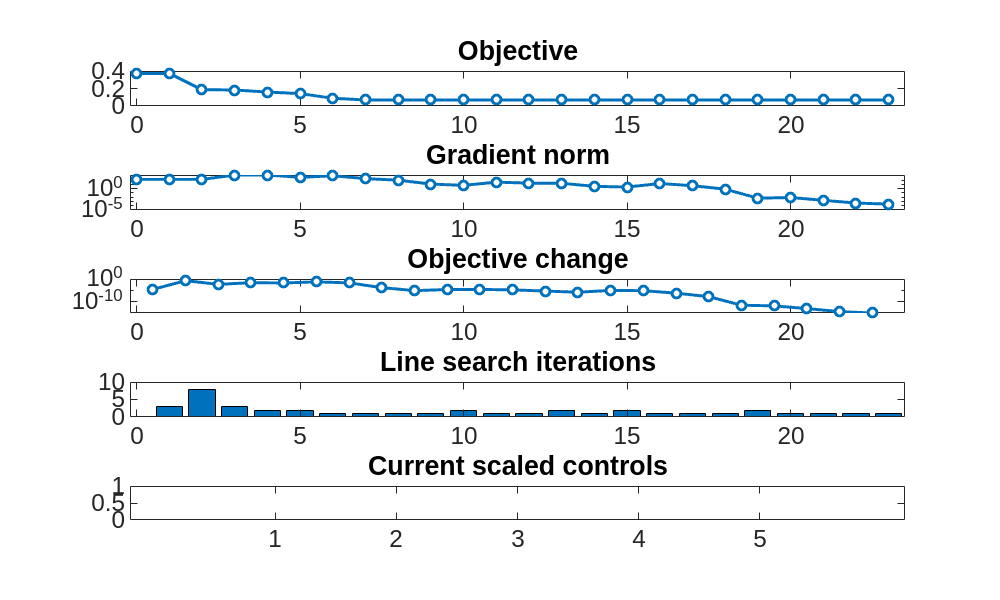

In [9]:
params0 = [3.84e-03,...
           2.71e-03,...
           6.00e+03,...
           9.48e-04,...
1.11e+01];              % initial condition: C1>2*C2

a = 1000;

pmin = params0 / a;
pmax = params0 * a;
scales = [pmin, pmax];

feis = FittingEIS(params0, scales, Z_re_exp, Z_im_exp, omega);

[~, ~, best_params, fitting_error] = feis.optimizationBFGS();


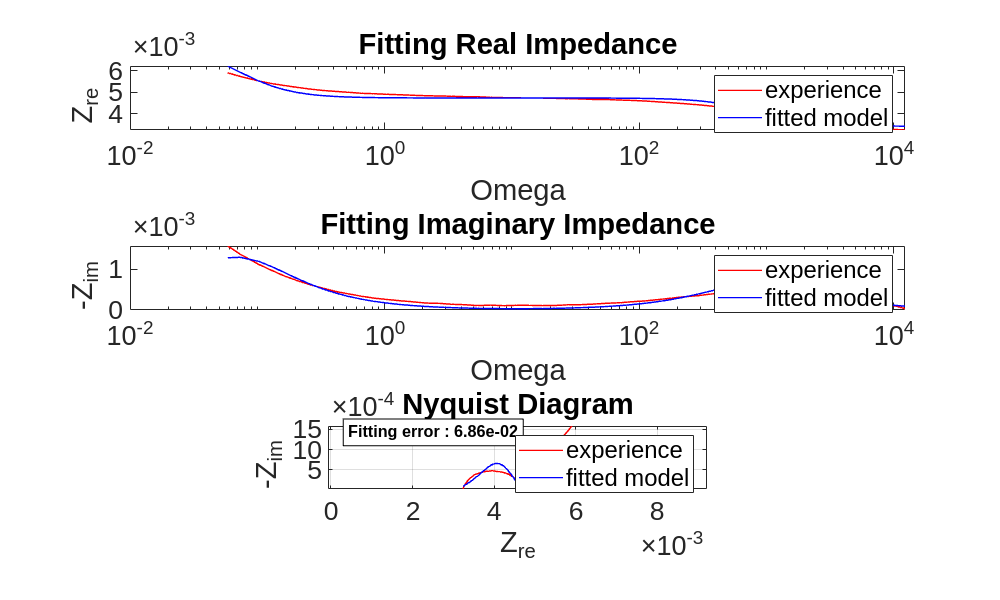

In [10]:

feis.plotresults_thevenin(best_params, fitting_error);

## Synthetic data from P2D model

We use impedance data generated from the P2d model with Chen et al's paper ([http://dx.doi.org/10.1149/1945\-7111/ab9050](http://dx.doi.org/10.1149/1945-7111/ab9050)) parameters


It:  0 | val: 5.457e+01 | ls-its: NaN | pgrad: 1.427e+05
It:  1 | val: 3.954e+01 | ls-its:   1 | pgrad: 1.427e+05
It:  2 | val: 1.472e+01 | ls-its:   1 | pgrad: 1.126e+05
Line search at max step size, Wolfe conditions not satisfied for this step.
Hessian not updated during iteration 3.
It:  3 | val: 1.177e+01 | ls-its:   4 | pgrad: 1.395e+03
It:  4 | val: 5.389e+00 | ls-its:   1 | pgrad: 5.470e+04
It:  5 | val: 5.370e+00 | ls-its:   1 | pgrad: 8.495e+03
It:  6 | val: 5.190e+00 | ls-its:   1 | pgrad: 8.371e+03
It:  7 | val: 4.888e+00 | ls-its:   1 | pgrad: 7.419e+03
It:  8 | val: 4.229e+00 | ls-its:   1 | pgrad: 1.211e+04
It:  9 | val: 3.452e+00 | ls-its:   1 | pgrad: 1.707e+04
It: 10 | val: 2.949e+00 | ls-its:   1 | pgrad: 1.621e+04
It: 11 | val: 2.819e+00 | ls-its:   1 | pgrad: 8.393e+03
It: 12 | val: 2.810e+00 | ls-its:   1 | pgrad: 1.636e+03
It: 13 | val: 2.810e+00 | ls-its:   1 | pgrad: 2.247e+02
It: 14 | val: 2.810e+00 | ls-its:   1 | pgrad: 2.239e+02
It: 15 | val: 2.810e+00 | ls-


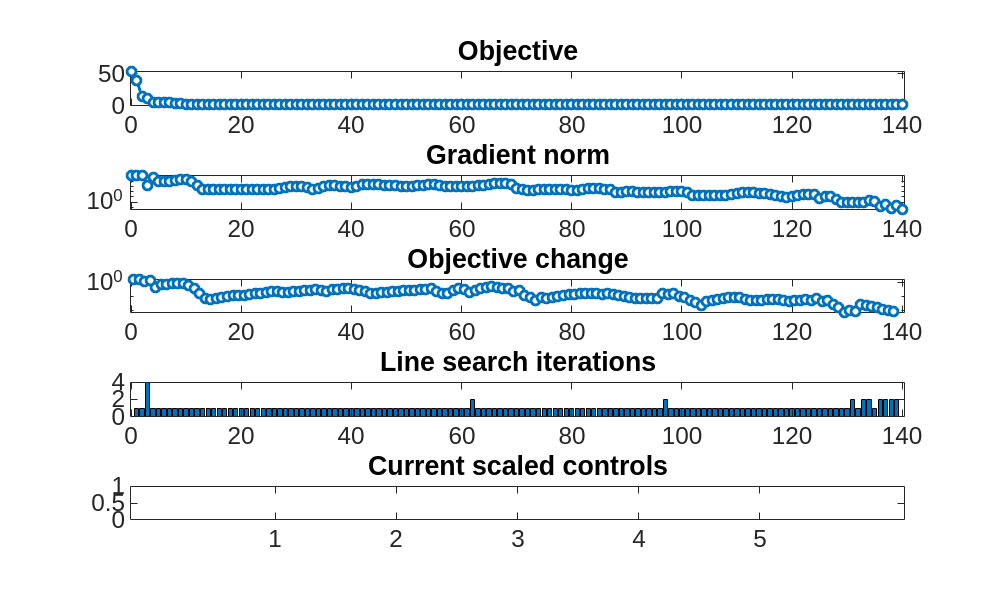

In [11]:
[Z_re_exp, Z_im_exp, omega] = load_chen_data();
params0 = [0.05052, 1.12673, 59119.9, 0.03155, 11054.0];  % initial condition: C1>2*C2

a = 1000;

pmin = params0 / a;
pmax = params0 * a;
scales = [pmin, pmax];

feis = FittingEIS(params0, scales, Z_re_exp, Z_im_exp, omega);

[~, ~, best_params, fitting_error] = feis.optimizationBFGS();


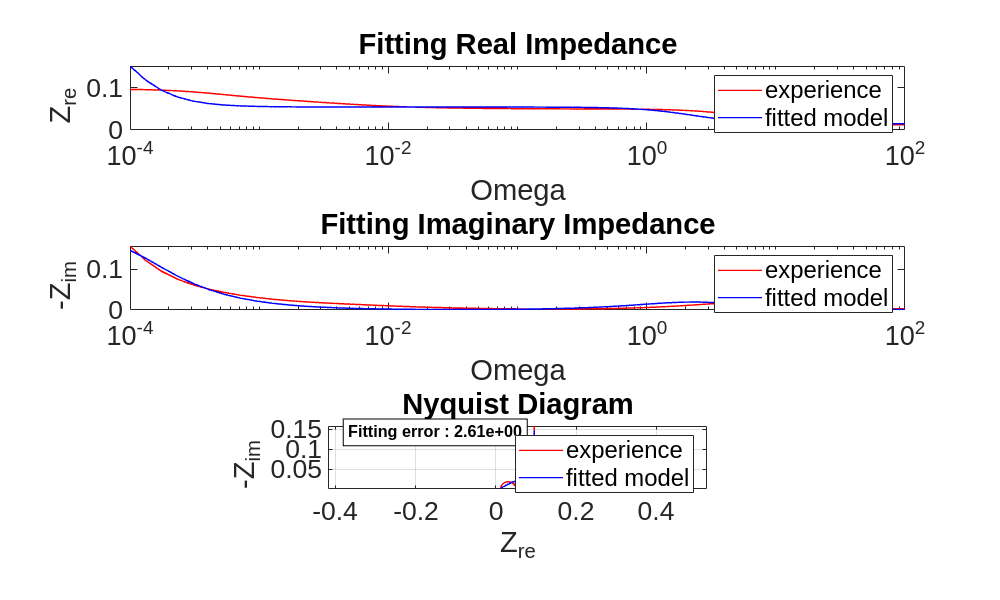

In [12]:
feis.plotresults_thevenin(best_params, fitting_error);